# 🍌 Análisis de Zonificación de Aptitud para Banano
## Valle del Cauca · UPRA (Escala 1:100.000)

---

### 📌 Contexto

Este notebook analiza la **zonificación de aptitud** para el cultivo comercial de banano (*Musa sp. AAA*) tipo exportación publicada por la **UPRA** a escala 1:100.000.

La zonificación clasifica el territorio en 5 categorías:
- 🟢 **Aptitud Alta**: Mejores condiciones físicas, socioecosistémicas y socioeconómicas
- 🟡 **Aptitud Media**: Limitaciones moderadas
- 🟠 **Aptitud Baja**: Fuertes limitaciones (requiere inversión/tecnología)
- 🔴 **No Apta**: Restricciones físicas que imposibilitan el cultivo
- ⬛ **Exclusión Legal**: Zonas donde la ley prohíbe el cultivo

### 🎯 Objetivo
1. Conocer la distribución de aptitud bananera en el Valle del Cauca
2. Identificar municipios con mayor potencial bananero
3. Calcular un **índice de aptitud municipal** para el modelo RFRK
4. Comparar la aptitud con los datos de rendimiento (EVA)

> **Fuente**: [datos.gov.co – Zonificación banano](https://www.datos.gov.co/Agricultura-y-Desarrollo-Rural/Zonificaci-n-de-aptitud-para-el-cultivo-comercial-/rcfj-3e57)

---
## 1️⃣ Configuración y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'figure.dpi': 100,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'font.family': 'sans-serif',
})

REPORT_DIR = os.path.join('../data', 'reports')
DATA_DIR = os.path.join('../data', 'processed')

# Colores para aptitudes
APTITUD_COLORS = {
    'Aptitud alta': '#27AE60',
    'Aptitud media': '#F1C40F',
    'Aptitud baja': '#E67E22',
    'No apta': '#E74C3C',
    'Exclusión legal': '#7F8C8D',
}
APTITUD_ORDER = ['Aptitud alta', 'Aptitud media', 'Aptitud baja', 'No apta', 'Exclusión legal']

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
# Cargar datos
df = pd.read_csv(os.path.join(DATA_DIR, 'zonificacion_banano_valle_limpio.csv'))
df_muni = pd.read_csv(os.path.join(DATA_DIR, 'zonificacion_banano_valle_municipio.csv'))

print(f'📊 Polígonos de zonificación: {len(df):,}')
print(f'📊 Municipios con datos:      {len(df_muni)}')
print(f'\n📋 Columnas del dataset municipal:')
for col in df_muni.columns:
    print(f'   - {col}')

📊 Polígonos de zonificación: 4,074
📊 Municipios con datos:      42

📋 Columnas del dataset municipal:
   - codigo_municipio
   - municipio
   - area_aptitud_alta_ha
   - area_aptitud_baja_ha
   - area_aptitud_media_ha
   - area_exclusion_legal_ha
   - area_no_apta_ha
   - area_total_ha
   - pct_aptitud_alta
   - pct_aptitud_baja
   - pct_aptitud_media
   - pct_exclusion_legal
   - pct_no_apta
   - aptitud_dominante
   - indice_aptitud_banano


---
## 2️⃣ ¿Qué tan apto es el Valle del Cauca para el banano?

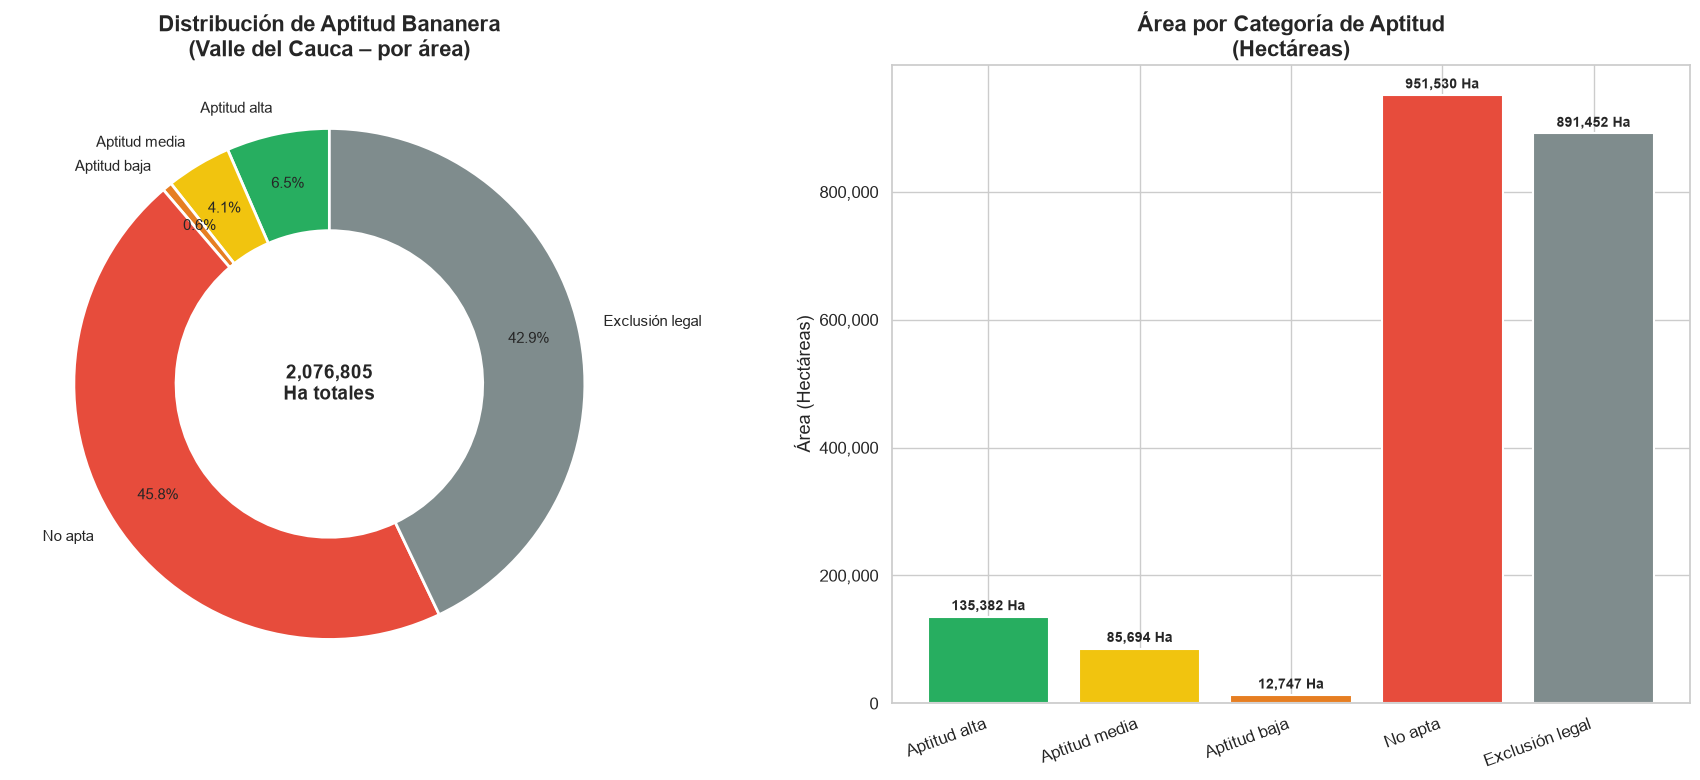


📊 Resumen:
   Aptitud alta        :    135,382.1 Ha (  6.5%)
   Aptitud media       :     85,693.6 Ha (  4.1%)
   Aptitud baja        :     12,747.0 Ha (  0.6%)
   No apta             :    951,530.4 Ha ( 45.8%)
   Exclusión legal     :    891,451.7 Ha ( 42.9%)


In [3]:
# Distribución de aptitud (por área)
area_por_aptitud = df.groupby('aptitud')['area_ha'].sum().reindex(APTITUD_ORDER)
area_total = area_por_aptitud.sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Gráfico de donut
colors = [APTITUD_COLORS[a] for a in area_por_aptitud.index]
wedges, texts, autotexts = axes[0].pie(
    area_por_aptitud.values, labels=area_por_aptitud.index,
    colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
axes[0].set_title('Distribución de Aptitud Bananera\n(Valle del Cauca – por área)')
# Centro del donut
axes[0].text(0, 0, f'{area_total:,.0f}\nHa totales', ha='center', va='center',
            fontsize=14, fontweight='bold')

# Gráfico de barras
bars = axes[1].bar(range(len(area_por_aptitud)), area_por_aptitud.values,
                  color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(area_por_aptitud)))
axes[1].set_xticklabels(area_por_aptitud.index, rotation=20, ha='right')
axes[1].set_ylabel('Área (Hectáreas)')
axes[1].set_title('Área por Categoría de Aptitud\n(Hectáreas)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

for bar, val in zip(bars, area_por_aptitud.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + area_total*0.005,
                f'{val:,.0f} Ha', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'fig_aptitud_banano_distribucion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Resumen:')
for apt in APTITUD_ORDER:
    area = area_por_aptitud.get(apt, 0)
    pct = (area / area_total) * 100
    print(f'   {apt:20s}: {area:>12,.1f} Ha ({pct:5.1f}%)')

---
## 3️⃣ Ranking de municipios por aptitud bananera

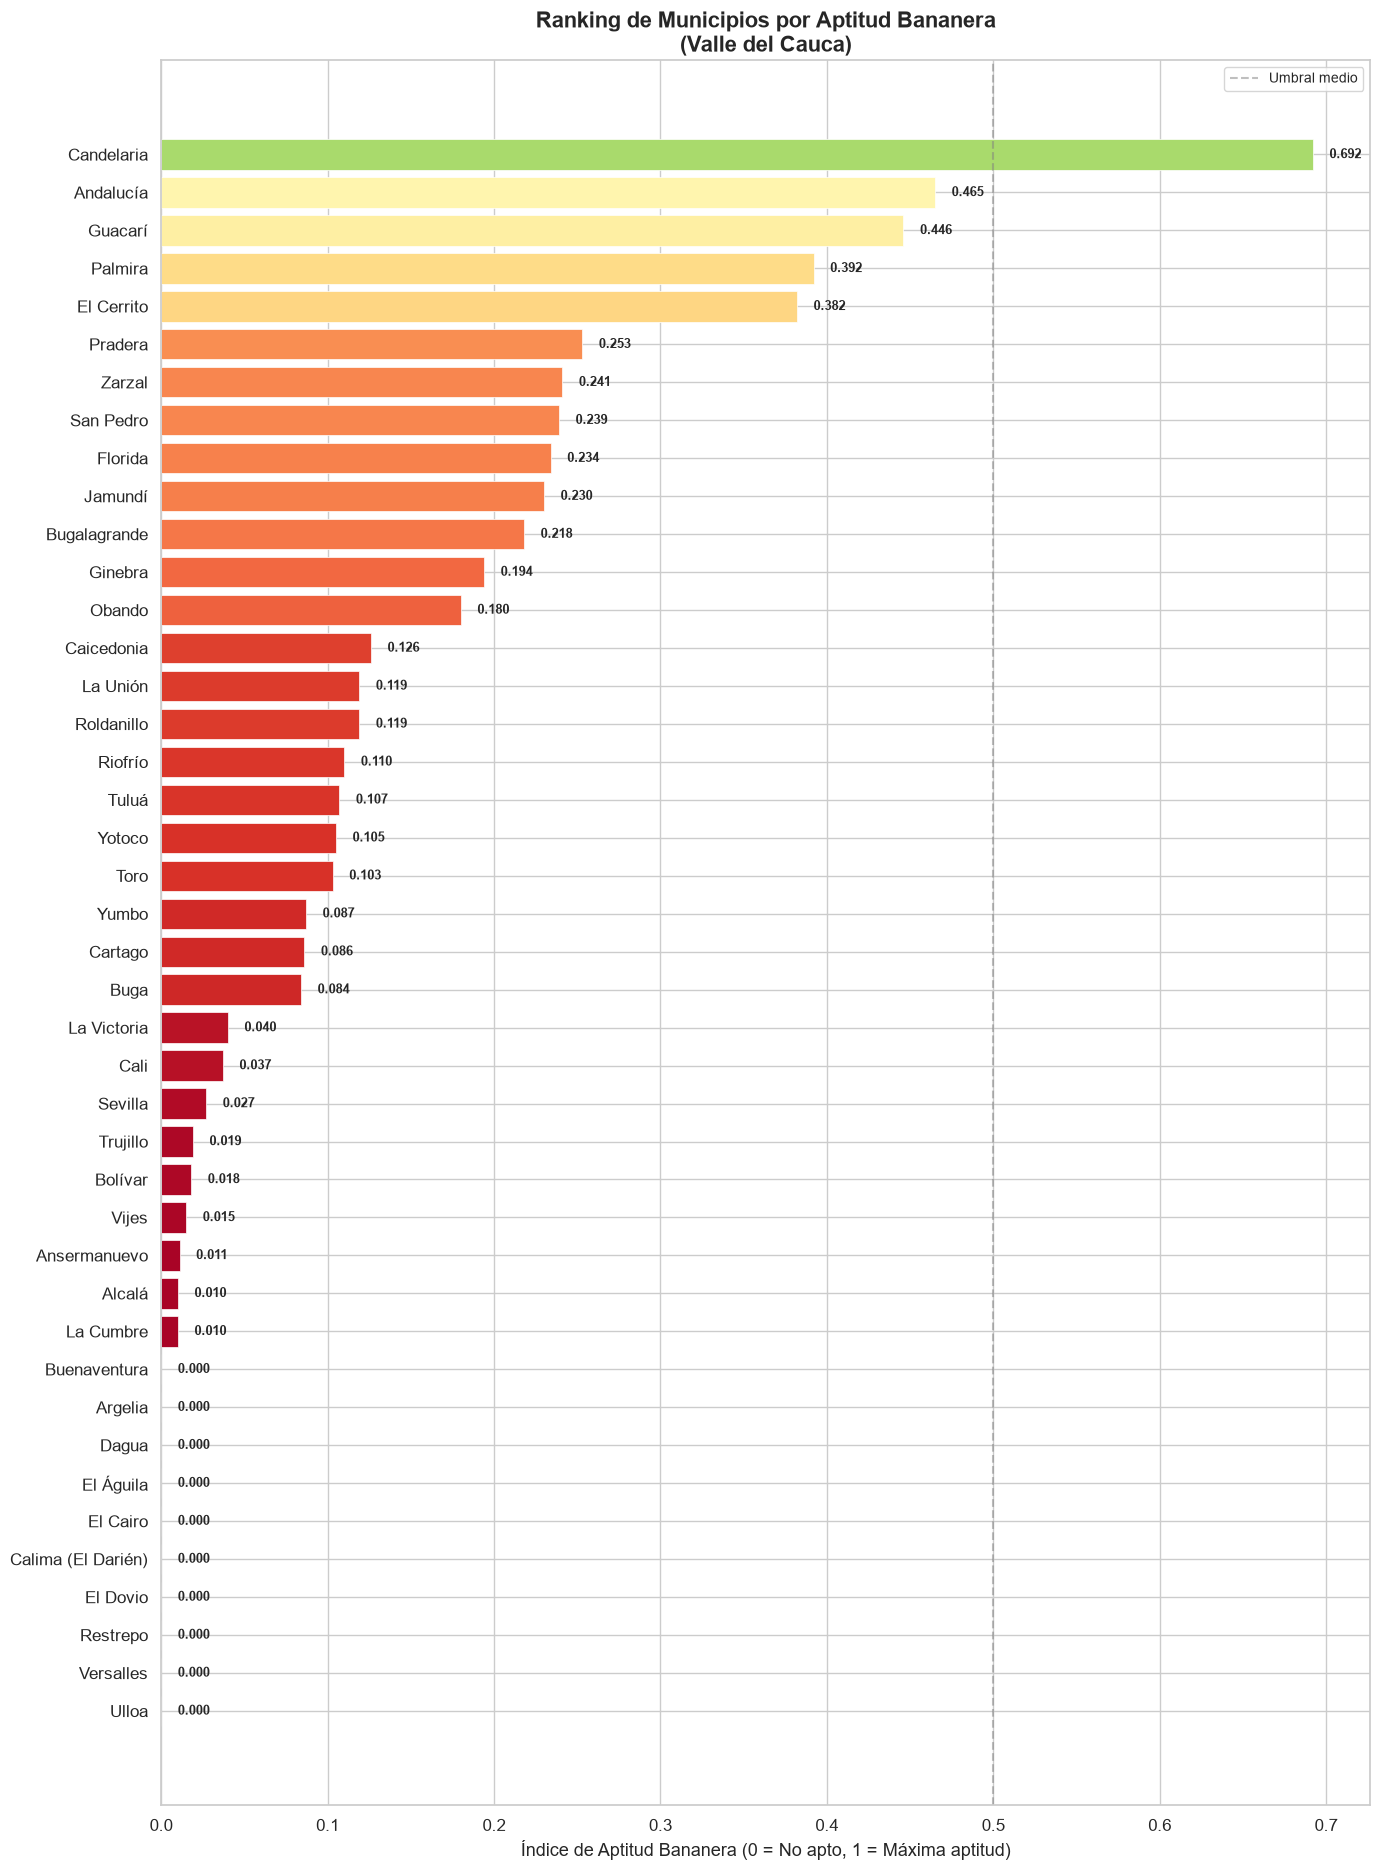

In [4]:
# Top municipios por índice de aptitud
df_sorted = df_muni.sort_values('indice_aptitud_banano', ascending=False).copy()

fig, ax = plt.subplots(figsize=(14, max(8, len(df_sorted) * 0.45)))

# Colores según el índice
colors = plt.cm.RdYlGn(df_sorted['indice_aptitud_banano'].values)
bars = ax.barh(df_sorted['municipio'][::-1], df_sorted['indice_aptitud_banano'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Índice de Aptitud Bananera (0 = No apto, 1 = Máxima aptitud)')
ax.set_title('Ranking de Municipios por Aptitud Bananera\n(Valle del Cauca)')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral medio')

for bar, val in zip(bars, df_sorted['indice_aptitud_banano'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'fig_ranking_aptitud_banano.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Tabla interactiva del ranking
cols_show = ['municipio', 'indice_aptitud_banano', 'aptitud_dominante', 'area_total_ha']
pct_cols = [c for c in df_muni.columns if c.startswith('pct_')]
cols_show.extend(pct_cols)

existing_cols = [c for c in cols_show if c in df_muni.columns]
print('📋 Ranking completo de municipios:')
df_muni[existing_cols].sort_values('indice_aptitud_banano', ascending=False)

📋 Ranking completo de municipios:


,municipio,indice_aptitud_banano,aptitud_dominante,area_total_ha,pct_aptitud_alta,pct_aptitud_baja,pct_aptitud_media,pct_exclusion_legal,pct_no_apta
11,Candelaria,0.692,Aptitud Media,29416.380285,40.79,2.17,41.51,3.81,11.72
2,Andalucía,0.465,No Apta,11103.673601,39.25,4.19,8.76,3.92,43.89
20,Guacarí,0.446,No Apta,16319.227255,24.15,6.90,27.29,12.43,29.23
26,Palmira,0.392,Exclusion Legal,100446.871157,33.20,0.36,8.75,37.80,19.89
16,El Cerrito,0.382,Exclusion Legal,44194.123608,24.76,0.65,19.77,32.14,22.68
27,Pradera,0.253,No Apta,35728.738988,7.82,1.31,25.54,17.43,47.90
41,Zarzal,0.241,No Apta,36800.721613,21.34,0.54,3.80,2.08,72.23
31,San Pedro,0.239,No Apta,21073.676284,17.67,1.61,8.51,3.32,68.88
18,Florida,0.234,No Apta,40387.259100,16.65,0.14,10.04,26.84,46.34
21,Jamundí,0.230,No Apta,62317.932746,15.19,3.51,9.98,26.95,44.37


---
## 4️⃣ Composición de aptitud por municipio

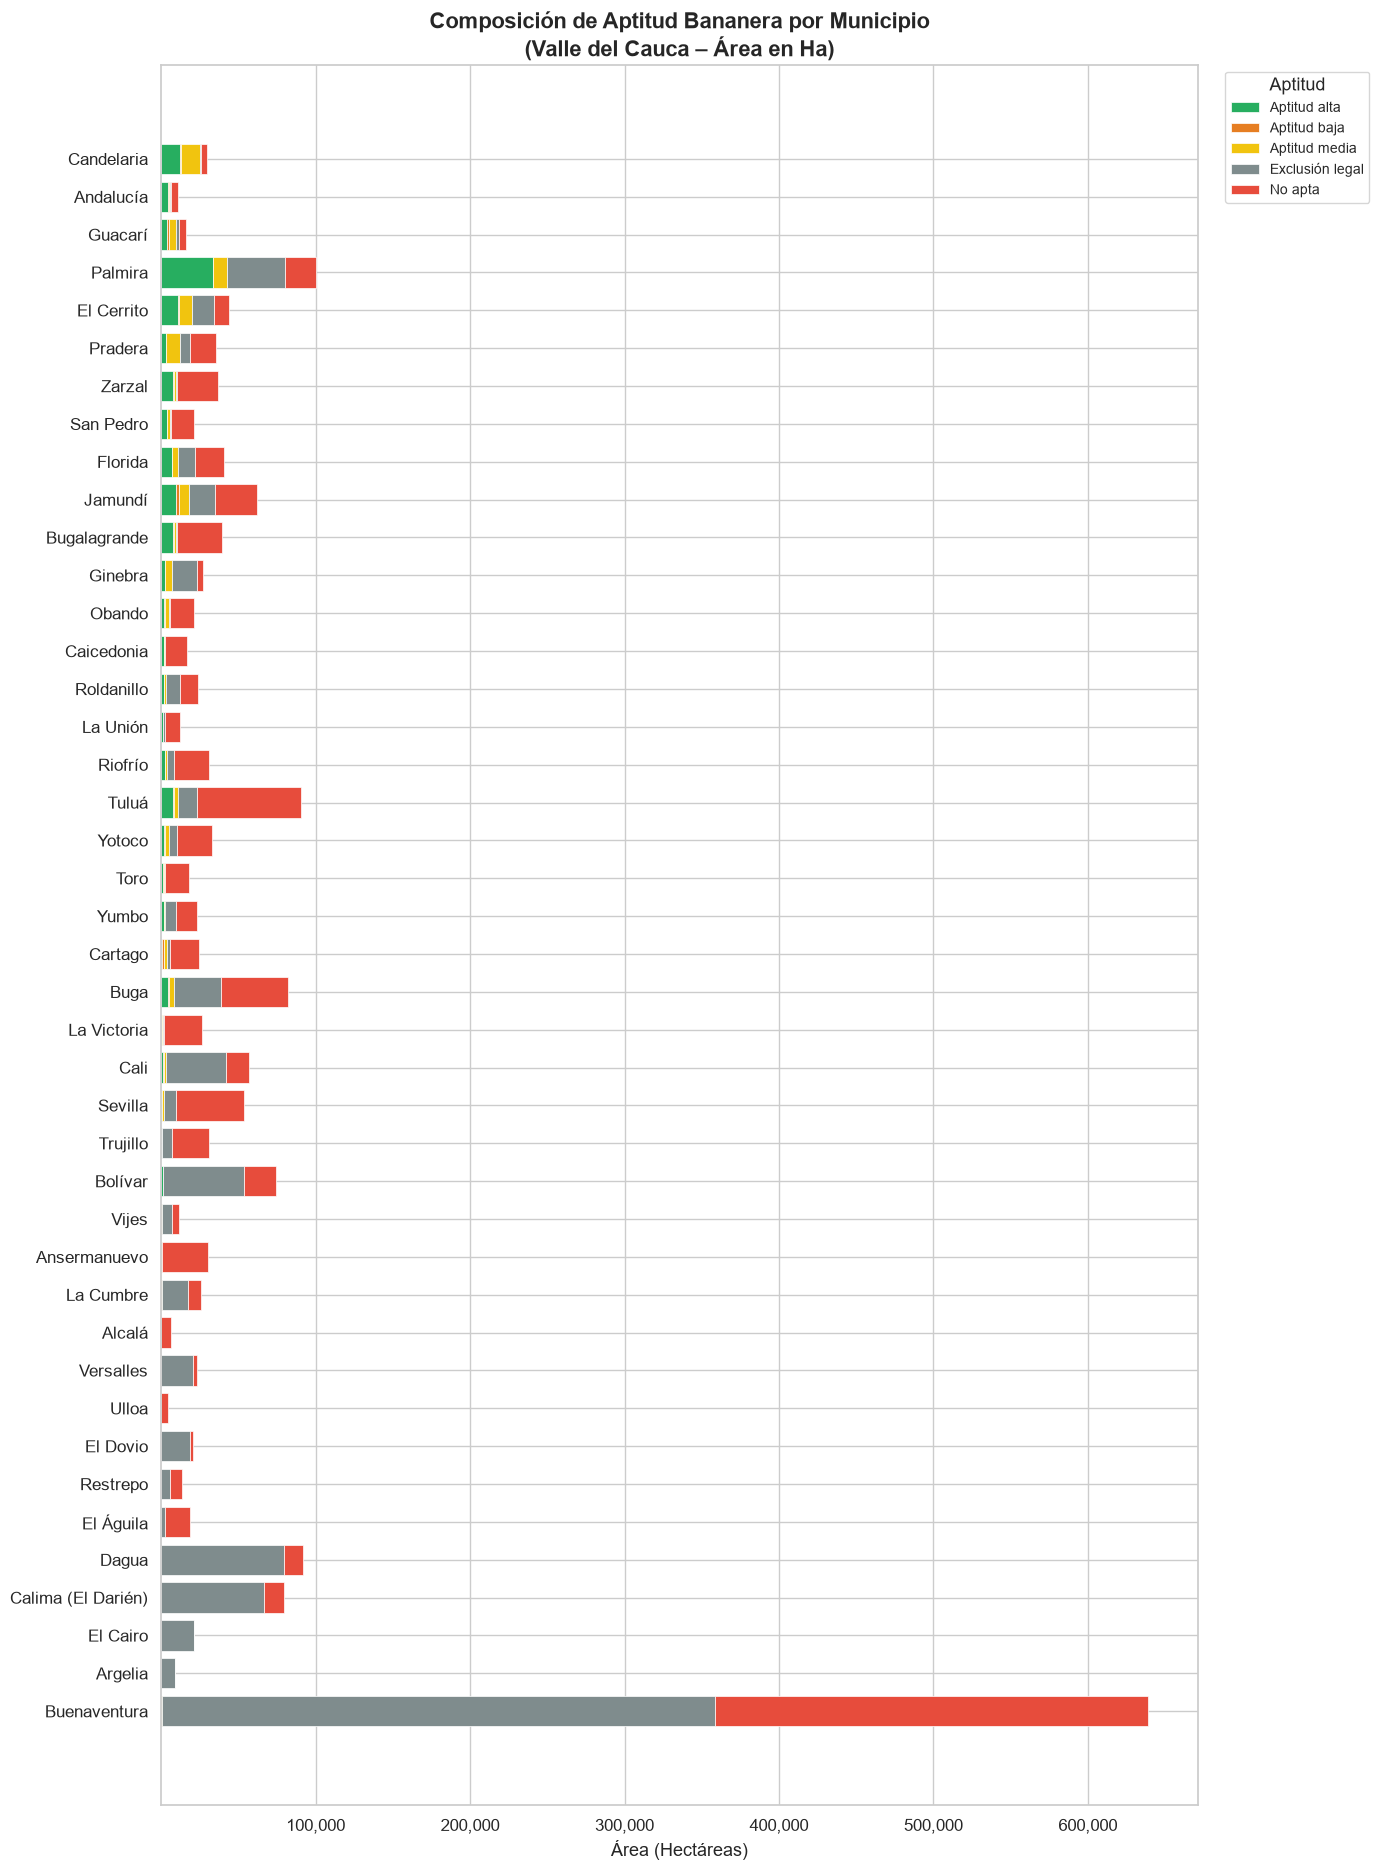

In [6]:
# Stacked bar chart: composición de aptitud por municipio
area_cols = [c for c in df_muni.columns if c.startswith('area_') and c.endswith('_ha') and c != 'area_total_ha']

if area_cols:
    df_plot = df_muni.sort_values('indice_aptitud_banano', ascending=True).copy()
    
    fig, ax = plt.subplots(figsize=(14, max(8, len(df_plot) * 0.45)))
    
    left = np.zeros(len(df_plot))
    for col in area_cols:
        label = col.replace('area_', '').replace('_ha', '').replace('_', ' ').title()
        color = APTITUD_COLORS.get(label, '#999')
        # Try to match aptitud colors
        for apt_key, apt_color in APTITUD_COLORS.items():
            if apt_key.lower().replace(' ', '_').replace('ó', 'o') in col:
                color = apt_color
                label = apt_key
                break
        ax.barh(df_plot['municipio'], df_plot[col], left=left, label=label,
               color=color, edgecolor='white', linewidth=0.5)
        left += df_plot[col].values
    
    ax.set_xlabel('Área (Hectáreas)')
    ax.set_title('Composición de Aptitud Bananera por Municipio\n(Valle del Cauca – Área en Ha)')
    ax.legend(title='Aptitud', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'fig_composicion_aptitud_banano_municipio.png'), dpi=150, bbox_inches='tight')
    plt.show()

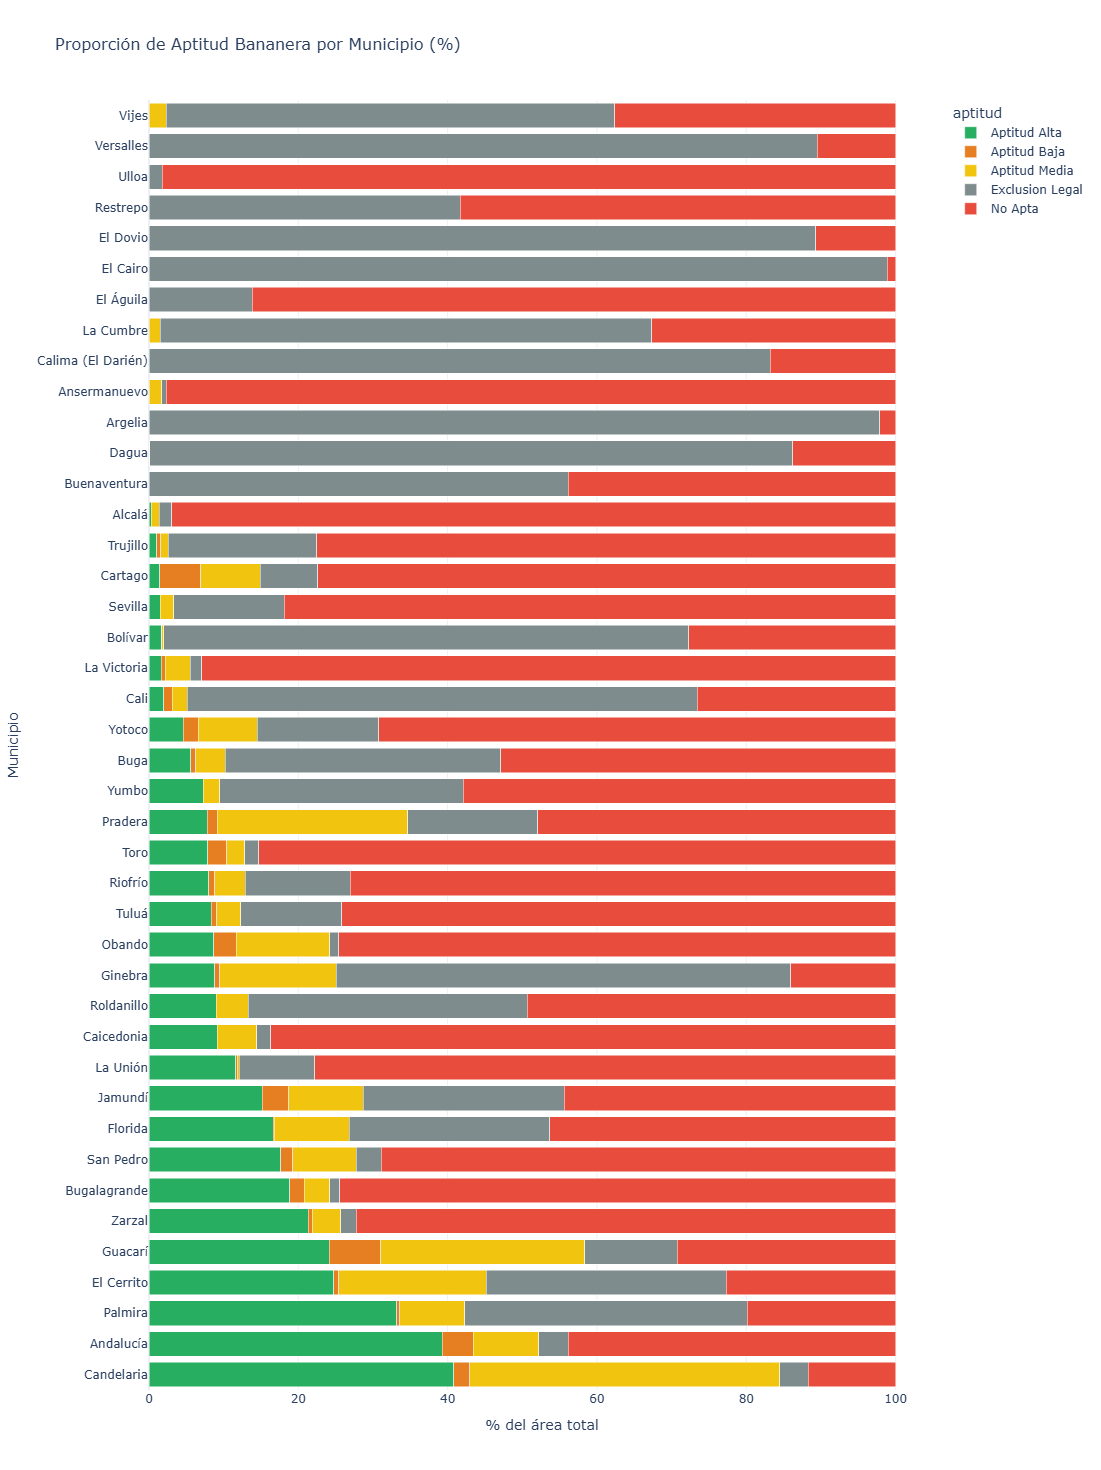

In [7]:
# Stacked bar chart interactivo (porcentajes)
pct_cols = [c for c in df_muni.columns if c.startswith('pct_')]

if pct_cols:
    df_pct = df_muni[['municipio'] + pct_cols].copy()
    df_pct = df_pct.sort_values(pct_cols[0] if pct_cols else 'municipio', ascending=False)
    
    # Reshape for plotly
    df_melted = df_pct.melt(id_vars='municipio', var_name='aptitud_pct', value_name='porcentaje')
    df_melted['aptitud'] = df_melted['aptitud_pct'].str.replace('pct_', '').str.replace('_', ' ').str.title()
    
    color_map = {}
    for apt_key, apt_color in APTITUD_COLORS.items():
        for melted_apt in df_melted['aptitud'].unique():
            if apt_key.lower().replace('ó', 'o') in melted_apt.lower().replace('ó', 'o'):
                color_map[melted_apt] = apt_color
    
    fig = px.bar(df_melted, x='porcentaje', y='municipio', color='aptitud',
                 orientation='h', barmode='stack',
                 color_discrete_map=color_map,
                 title='Proporción de Aptitud Bananera por Municipio (%)',
                 labels={'porcentaje': '% del área total', 'municipio': 'Municipio'},
                 template='plotly_white', height=max(400, len(df_muni) * 35))
    fig.update_layout(font=dict(size=12), title_font_size=16)
    fig.show()

---
## 5️⃣ Análisis de tamaño de polígonos

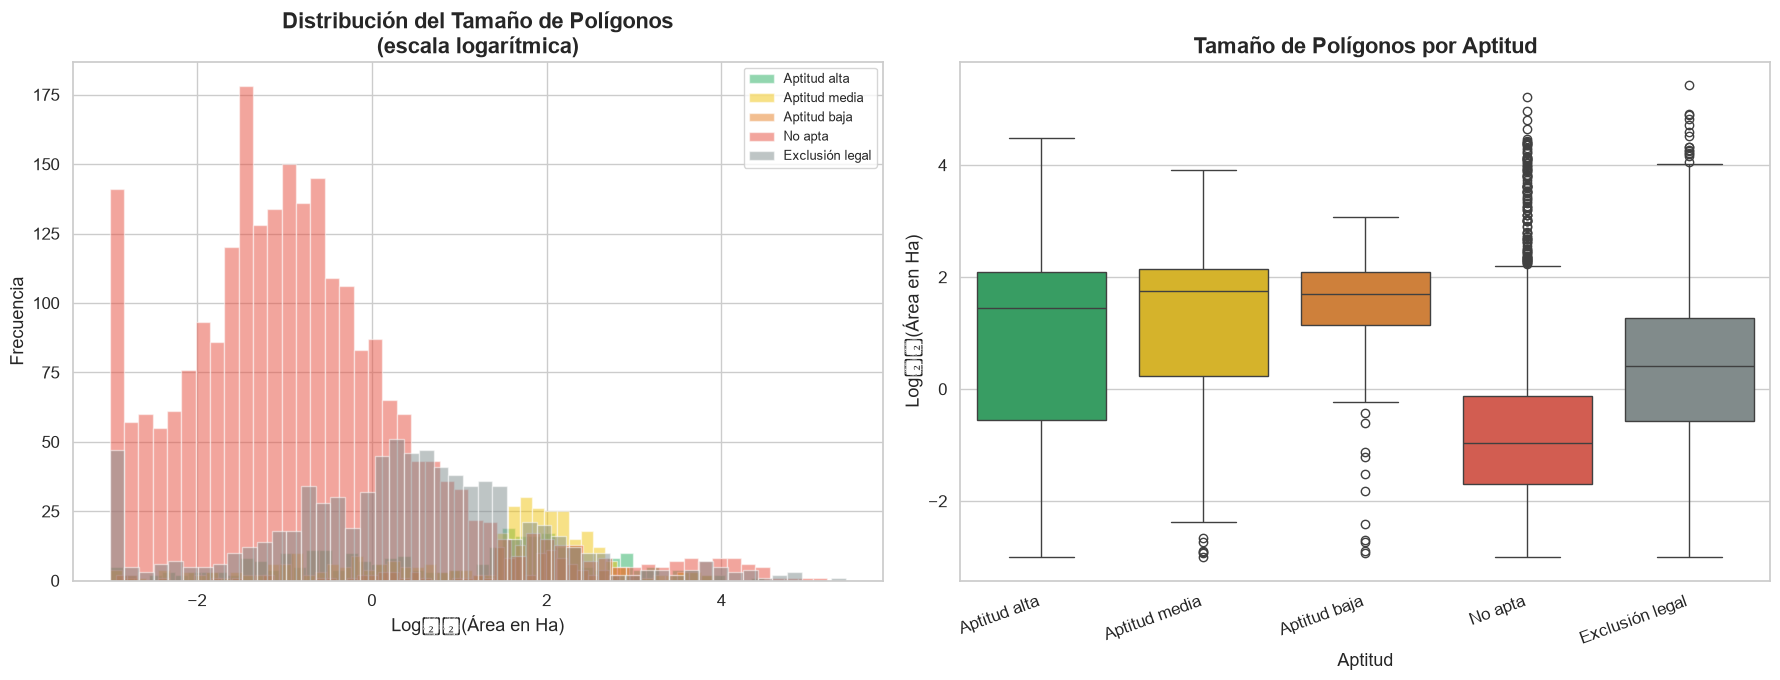

In [8]:
# Distribución del tamaño de polígonos por aptitud
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Histograma (log scale)
for apt in APTITUD_ORDER:
    data = df[df['aptitud'] == apt]['area_ha']
    if len(data) > 0:
        axes[0].hist(np.log10(data[data > 0] + 0.001), bins=50, alpha=0.5,
                    label=apt, color=APTITUD_COLORS[apt])
axes[0].set_xlabel('Log₁₀(Área en Ha)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Tamaño de Polígonos\n(escala logarítmica)')
axes[0].legend(fontsize=9)

# Boxplot
df_box = df[df['area_ha'] > 0].copy()
df_box['log_area'] = np.log10(df_box['area_ha'] + 0.001)
order = APTITUD_ORDER
existing_order = [a for a in order if a in df_box['aptitud'].unique()]
sns.boxplot(data=df_box, x='aptitud', y='log_area', order=existing_order,
           palette=APTITUD_COLORS, ax=axes[1])
axes[1].set_xlabel('Aptitud')
axes[1].set_ylabel('Log₁₀(Área en Ha)')
axes[1].set_title('Tamaño de Polígonos por Aptitud')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'fig_tamano_poligonos_banano.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6️⃣ Cruce con datos de rendimiento (EVA)

✅ Cruce exitoso: 39 municipios en común



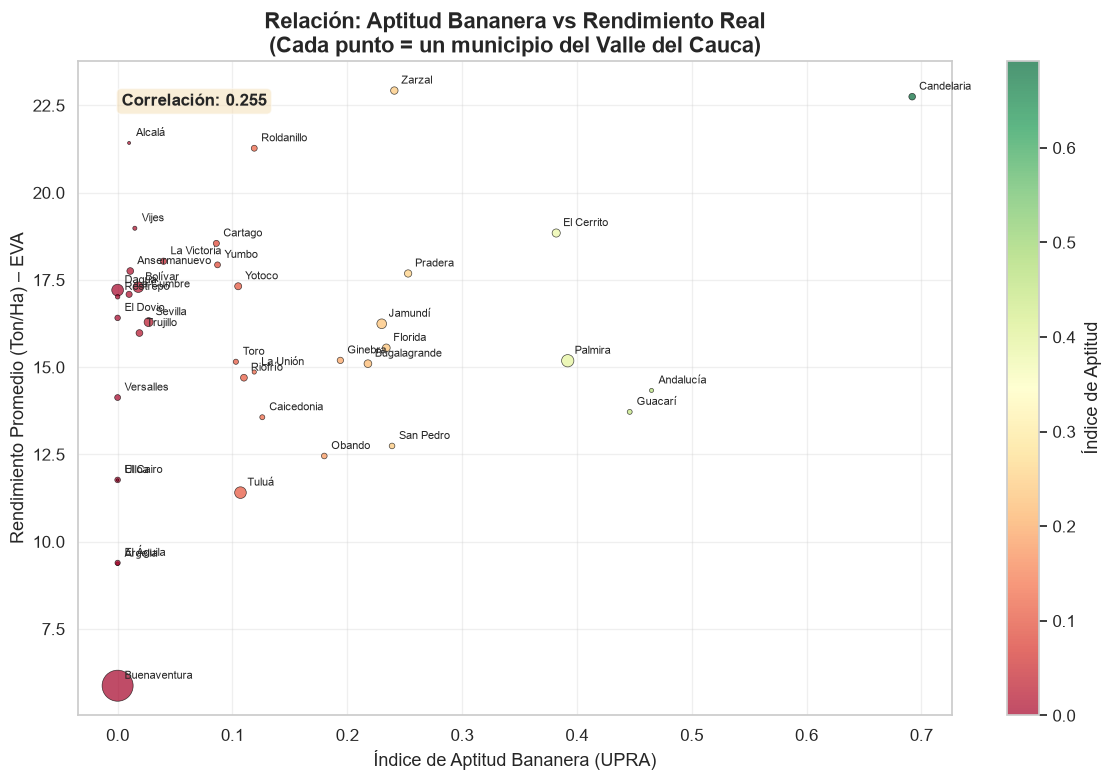


📊 Correlación Aptitud ↔ Rendimiento: 0.255
   → Correlación débil: otros factores (clima, manejo) influyen más que la aptitud base


In [13]:
# Cruzar aptitud con rendimiento del banano
try:
    df_eva_banano = pd.read_csv(os.path.join(DATA_DIR, 'eva_valle_del_cauca_all.csv'))
    
    # Rendimiento promedio por municipio (EVA)
    rend_muni = df_eva_banano.groupby('municipio')['rendimiento_ton_ha'].mean().reset_index()
    rend_muni.columns = ['municipio_eva', 'rendimiento_promedio']
    
    # Intentar hacer merge (nombres pueden diferir)
    # Normalizar nombres para comparación
    df_muni_copy = df_muni.copy()
    df_muni_copy['municipio_upper'] = df_muni_copy['municipio'].str.upper().str.strip()
    rend_muni['municipio_upper'] = rend_muni['municipio_eva'].str.upper().str.strip()
    
    merged = df_muni_copy.merge(rend_muni, on='municipio_upper', how='inner')
    
    if len(merged) > 0:
        print(f'✅ Cruce exitoso: {len(merged)} municipios en común\n')
        
        # Scatter: Aptitud vs Rendimiento
        fig, ax = plt.subplots(figsize=(12, 8))
        scatter = ax.scatter(merged['indice_aptitud_banano'], merged['rendimiento_promedio'],
                           s=merged['area_total_ha'] / merged['area_total_ha'].max() * 500,
                           c=merged['indice_aptitud_banano'], cmap='RdYlGn',
                           alpha=0.7, edgecolors='black', linewidth=0.5)
        
        for _, row in merged.iterrows():
            ax.annotate(row['municipio'], (row['indice_aptitud_banano'], row['rendimiento_promedio']),
                       textcoords='offset points', xytext=(5, 5), fontsize=8)
        
        ax.set_xlabel('Índice de Aptitud Bananera (UPRA)')
        ax.set_ylabel('Rendimiento Promedio (Ton/Ha) – EVA')
        ax.set_title('Relación: Aptitud Bananera vs Rendimiento Real\n(Cada punto = un municipio del Valle del Cauca)')
        plt.colorbar(scatter, label='Índice de Aptitud')
        ax.grid(True, alpha=0.3)
        
        # Calcular correlación
        corr = merged['indice_aptitud_banano'].corr(merged['rendimiento_promedio'])
        ax.text(0.05, 0.95, f'Correlación: {corr:.3f}', transform=ax.transAxes,
               fontsize=12, fontweight='bold', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(os.path.join(REPORT_DIR, 'fig_aptitud_banano_vs_rendimiento.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f'\n📊 Correlación Aptitud ↔ Rendimiento: {corr:.3f}')
        if abs(corr) > 0.5:
            print('   → Correlación significativa: la aptitud es un buen predictor')
        elif abs(corr) > 0.3:
            print('   → Correlación moderada: la aptitud aporta información pero no es suficiente sola')
        else:
            print('   → Correlación débil: otros factores (clima, manejo) influyen más que la aptitud base')
    else:
        print('⚠️ No se pudieron cruzar los municipios (verificar nombres)')
    
except FileNotFoundError:
    print('⚠️ No se encontró el dataset EVA de banano. Asegúrate de haber procesado EVA para banano.')

---
## 7️⃣ Municipios con potencial de mejora

📋 Clasificación de municipios bananeros:

  💪 Bajo potencial + Alto rendimiento (eficientes):
    - Alcalá (aptitud: 0.010, rendimiento: 21.43 T/Ha)
    - Ansermanuevo (aptitud: 0.011, rendimiento: 17.76 T/Ha)
    - Bolívar (aptitud: 0.018, rendimiento: 17.29 T/Ha)
    - Cartago (aptitud: 0.086, rendimiento: 18.55 T/Ha)
    - Dagua (aptitud: 0.000, rendimiento: 17.21 T/Ha)
    - El Dovio (aptitud: 0.000, rendimiento: 16.41 T/Ha)
    - La Cumbre (aptitud: 0.010, rendimiento: 17.09 T/Ha)
    - La Victoria (aptitud: 0.040, rendimiento: 18.04 T/Ha)
    - Restrepo (aptitud: 0.000, rendimiento: 17.02 T/Ha)
    - Sevilla (aptitud: 0.027, rendimiento: 16.29 T/Ha)
    - Trujillo (aptitud: 0.019, rendimiento: 15.98 T/Ha)
    - Vijes (aptitud: 0.015, rendimiento: 18.98 T/Ha)
    - Yumbo (aptitud: 0.087, rendimiento: 17.93 T/Ha)

  🎯 Alto potencial + Bajo rendimiento (OPORTUNIDAD):
    - Andalucía (aptitud: 0.465, rendimiento: 14.33 T/Ha)
    - Bugalagrande (aptitud: 0.218, rendimiento: 15.10 T/Ha

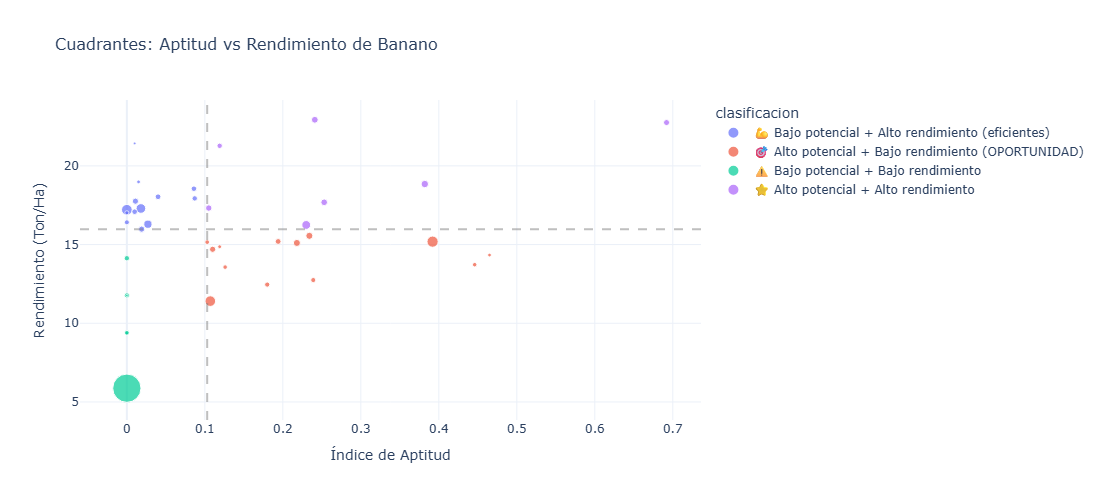

In [14]:
# Identificar municipios con alta aptitud pero bajo aprovechamiento actual
# (alta aptitud = mucha área apta, bajo rendimiento = oportunidad de mejora)

try:
    if len(merged) > 0:
        # Clasificar municipios
        apt_median = merged['indice_aptitud_banano'].median()
        rend_median = merged['rendimiento_promedio'].median()
        
        merged['clasificacion'] = 'Sin clasificar'
        merged.loc[(merged['indice_aptitud_banano'] >= apt_median) & 
                   (merged['rendimiento_promedio'] >= rend_median), 'clasificacion'] = '⭐ Alto potencial + Alto rendimiento'
        merged.loc[(merged['indice_aptitud_banano'] >= apt_median) & 
                   (merged['rendimiento_promedio'] < rend_median), 'clasificacion'] = '🎯 Alto potencial + Bajo rendimiento (OPORTUNIDAD)'
        merged.loc[(merged['indice_aptitud_banano'] < apt_median) & 
                   (merged['rendimiento_promedio'] >= rend_median), 'clasificacion'] = '💪 Bajo potencial + Alto rendimiento (eficientes)'
        merged.loc[(merged['indice_aptitud_banano'] < apt_median) & 
                   (merged['rendimiento_promedio'] < rend_median), 'clasificacion'] = '⚠️ Bajo potencial + Bajo rendimiento'
        
        # Mostrar clasificación
        print('📋 Clasificación de municipios bananeros:\n')
        for clasif in merged['clasificacion'].unique():
            munis = merged[merged['clasificacion'] == clasif]['municipio'].tolist()
            print(f'  {clasif}:')
            for m in munis:
                row = merged[merged['municipio'] == m].iloc[0]
                print(f'    - {m} (aptitud: {row["indice_aptitud_banano"]:.3f}, rendimiento: {row["rendimiento_promedio"]:.2f} T/Ha)')
            print()
        
        # Gráfico de cuadrantes
        fig = px.scatter(merged, x='indice_aptitud_banano', y='rendimiento_promedio',
                        color='clasificacion', hover_name='municipio',
                        size='area_total_ha',
                        title='Cuadrantes: Aptitud vs Rendimiento de Banano',
                        labels={'indice_aptitud_banano': 'Índice de Aptitud',
                                'rendimiento_promedio': 'Rendimiento (Ton/Ha)'},
                        template='plotly_white')
        fig.add_hline(y=rend_median, line_dash='dash', line_color='gray', opacity=0.5)
        fig.add_vline(x=apt_median, line_dash='dash', line_color='gray', opacity=0.5)
        fig.update_layout(font=dict(size=12), title_font_size=16, height=500)
        fig.show()
except:
    print('⚠️ Requiere datos de EVA para esta sección')

---
## 8️⃣ Resumen ejecutivo y conclusiones

### ✅ Hallazgos principales

| Aspecto | Resultado |
|---------|----------|
| **Tipo de datos** | Zonificación de aptitud a escala 1:100.000 |
| **Categorías** | 5 niveles: Alta, Media, Baja, No apta, Exclusión legal |
| **Cobertura** | Todos los municipios del Valle del Cauca |
| **Variable derivada** | Índice de aptitud municipal (0–1) |
| **Naturaleza** | Datos estáticos (no cambian con el tiempo) |

### 🎯 Evaluación para el modelo RFRK

| Criterio | Evaluación |
|----------|------------|
| ¿Es útil como predictor? | ✅ **SÍ** – Aptitud agroecológica base |
| ¿Se puede cruzar con EVA? | ✅ **SÍ** – Por código municipio DANE |
| ¿Tiene variabilidad espacial? | ✅ **SÍ** – Varía significativamente entre municipios |
| ¿Es predictor independiente? | ✅ **SÍ** – Captura factores biofísicos |
| ¿Limitación principal? | ⚠️ Estático, no refleja manejo ni cambio climático |


In [15]:
print('=' * 60)
print('RESUMEN – ZONIFICACIÓN DE BANANO – VALLE DEL CAUCA')
print('=' * 60)
print(f'Fuente: UPRA – datos.gov.co (ID: rcfj-3e57)')
print(f'Escala: 1:100.000')
print(f'Polígonos: {len(df):,}')
print(f'Municipios: {len(df_muni)}')
print(f'\nÁrea total evaluada: {df["area_ha"].sum():,.0f} Ha')
print(f'\nArchivos generados:')
print(f'  - zonificacion_banano_valle_limpio.csv ({len(df):,} polígonos)')
print(f'  - zonificacion_banano_valle_municipio.csv ({len(df_muni)} municipios)')
print(f'\n✅ DATASET VALIDADO Y APTO COMO PREDICTOR DE APTITUD')

RESUMEN – ZONIFICACIÓN DE BANANO – VALLE DEL CAUCA
Fuente: UPRA – datos.gov.co (ID: rcfj-3e57)
Escala: 1:100.000
Polígonos: 4,074
Municipios: 42

Área total evaluada: 2,076,805 Ha

Archivos generados:
  - zonificacion_banano_valle_limpio.csv (4,074 polígonos)
  - zonificacion_banano_valle_municipio.csv (42 municipios)

✅ DATASET VALIDADO Y APTO COMO PREDICTOR DE APTITUD
